# Officina 006: screened-continuation

This iteration runs the production generation, page drawing, synthetic handwriting, reading and continuation functions through one game. The household and replies are synthetic. Cloud calls incur usage. No physical printer, camera, deployed HTTP API, parent approval or household clock is exercised. Declared minutes are document timings, not measured human time.

Acceptance requires an explicit close, multiple written returns and generated sheets, at most five sheets, a continuation receiving the returned descriptions, and an untouched-page control read as blank. Repeated continuations still receive the original approved plan, as in the current hub; the record must reveal any limitation this causes.

In [1]:
from __future__ import annotations

import importlib
import io
import json
import os
import subprocess
import sys
import time
from datetime import UTC, datetime
from pathlib import Path

from IPython.display import Image, Markdown, display
from PIL import Image as Picture

START = Path.cwd().resolve()
ROOT = next(
    candidate for candidate in (START, *START.parents)
    if (candidate / 'pyproject.toml').is_file() and (candidate / 'research').is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
bench = importlib.import_module('research.bench')
settings = bench.environment()
FINGERPRINT = bench.reload_prompts()
ITERATION = '006-screened-continuation'
RUN = ROOT / 'officina' / 'runs' / (
    ITERATION + '-' + datetime.now(UTC).strftime('%Y%m%dT%H%M%S%fZ')
)
print('Interpreter:', sys.executable)
print('Prompt fingerprint:', FINGERPRINT)
print('Artifacts:', RUN.relative_to(ROOT))
print('Cloud configuration loaded; credentials are not displayed.')
PROMPT_SNAPSHOT = {
    str(path.relative_to(ROOT)): path.read_text(encoding="utf-8")
    for package in ("agents", "shared")
    for path in (ROOT / package).glob("*.md")
}
PROVENANCE = {
    "iteration": ITERATION,
    "prompt_fingerprint": FINGERPRINT,
    "git_head": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
    ).strip(),
    "synthetic": True,
}


Interpreter: C:\code\lanternina\.venv\Scripts\python.exe
Prompt fingerprint: 22fa7d484a58
Artifacts: officina\runs\006-screened-continuation-20260915T144851952272Z
Cloud configuration loaded; credentials are not displayed.


## Synthetic Household

The game alternates printed messages and written replies. Each sheet supplies the instructions and material needed for its exchange. The ceiling includes any closing print.

In [2]:
from panel.preferences import DEFAULT_SHEETS
from research.households import Household, Memory, arguments

HOUSE = Household(
    name='officina-001-synthetic', interests=('le mappe', 'i luoghi inventati'),
    avoid=('la guerra',), sheets=DEFAULT_SHEETS,
)
ARGS = arguments(HOUSE, Memory())
ARGS['brief'] = (
    'Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. '
    'Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o '
    'disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno '
    'tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un '
    'dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi '
    'ask quando serve leggere il contenuto per decidere la risposta. Arriva a una '
    'chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti '
    'e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da '
    'lettura, stampa e aggiornamento del display; non promettere risposte immediate. '
    'Tutte le informazioni per agire devono essere sulla carta o nei messaggi. '
    'Tutto il materiale e sintetico.'
)
print('Sheet ceiling:', ARGS['sheets'])
print(ARGS['brief'])

Sheet ceiling: 5
Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi ask quando serve leggere il contenuto per decidere la risposta. Arriva a una chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da lettura, stampa e aggiornamento del display; non promettere risposte immediate. Tutte le informazioni per agire devono essere sulla carta o nei messaggi. Tutto il materiale e sintetico.


## Local Checks

These tests exercise the simulator and handwriting helpers without cloud models. They distinguish a conclusion from a stop, degraded reading or failed print. They do not validate a physical game.

In [3]:
test_environment = {
    key: value for key, value in os.environ.items()
    if not (key.startswith('LANTERNINA_') and
            any(part in key for part in ('FOUNDRY', 'CONTENT_SAFETY', 'SAFETY')))
}
began = time.perf_counter()
checked = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/test_workbench.py',
     'tests/test_handwriting.py', '-q'],
    env=test_environment, capture_output=True, text=True, encoding='utf-8',
)
print(checked.stdout)
print(checked.stderr)
print(f'Elapsed: {time.perf_counter() - began:.1f} s')
checked.check_returncode()

.................                                                        [100%]
17 passed in 5.88s


Elapsed: 8.1 s


## The Complete Game

This cell calls paid services and keeps logical prompts, responses, generated sheets and synthetic returns in the run directory. Images below are reduced previews; full-size images remain in the artifacts. The simulator advances non-collection moments immediately and does not reproduce display latency. Its step limit reports interruption, never success.


--- SENT: choosing what to build an afternoon out of ---
You are about to devise one activity for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["le mappe", "i luoghi inventati"]
And these things to keep away from: ["la guerra"]
Activities already offered here: []
How the activity should be pitched: nothing is known about this house yet

Choose one form and one move. Choose what would make the best activity for this house — not what is easiest to write, and not the first one that looks familiar. If the interests point at something, let them; if nothing fits them, choose the form that would make the strangest good activity r

--- RETURNED: choosing what to build an afternoon out of (16.91 s) ---


{"form":"plan-of-a-place-you-know","move":"named-by-what-happens-there","why":"Trasforma un luogo familiare in una mappa di posti inventati, chiamati in base a ciò che vi accade."}



--- SENT: devising an afternoon ---
You are making one activity for one adolescent to spend at home, mostly on their own. The household capabilities below say which displays, printing and return channels are available. A handheld camera can show Lanternina the work that has been made, including paper when sheet reading is enabled. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when these things are true of it.

Somebody can

--- RETURNED: devising an afternoon (93.113 s) ---


{"title":"L’atlante della stanza che cambia funzione","overview":"Misura una stanza con passi, un libro o un piede, ne disegna la pianta e la trasforma in un luogo inventato. Dalla stampante escono fogli d’atlante personalizzati. Alla fine tiene una mappa completa con scala, percorso, ostacolo e legenda. Non serve altro oltre a carta e matita. Potrebbe non piacere dover misurare la stanza e ridisegnarla quando la prima scala non entra.","themes":["mappe","luoghi inventati","scale","trasformazioni","percorsi"],"script":"IL MONDO\nUna stanza reale diventa la matrice geometrica di un luogo inventato. Pareti, aperture e ingombri vengono misurati con un’unità corporea o domestica. Lanternina aggiunge conseguenze alle scelte ricevute. L’atlante, i nomi e le proprietà del luogo sono elementi fittizi; le misure e la prima pianta sono osservazioni reali.\n\nLA VIA D’ENTRATA\nLa stampante consegna il foglio di rilievo. Sul display Lanternina segnala che la stanza eccede il foglio. Si prende il f

[1] hand_over: La stanza eccede



--- SENT: drawing a notebook ---
The page is a leaf out of a field notebook: a margin rule down the left and a quick sketch in one corner. Rule lines only where the page asks for something to be written, and leave the paper plain everywhere else.

Letter this large, as the title: "Stanza matrice, primo rilievo"
Letter this smaller, under the title: "Misura una stanza nota usando sempre passi, un libro oppure un piede. Scegli quanto vale una unità sulla pagina e scrivi entrambe le regole. Traccia pareti, aperture e due ingombri; un solo ingombro basta. Nomina il luogo per ciò che vi accade; poi mostra questo foglio."
Leave one ruled line, long enough for a few words, with "La mia unità costante" lettered above it
Leave one ruled line, long enough for a few words, with "Sulla pagina, una unità vale" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Pianta: pareti, aperture, ingombri" lettered above it
Leave one ruled line, long enough for a few words

--- RETURNED: drawing a notebook (38.471 s) ---


...


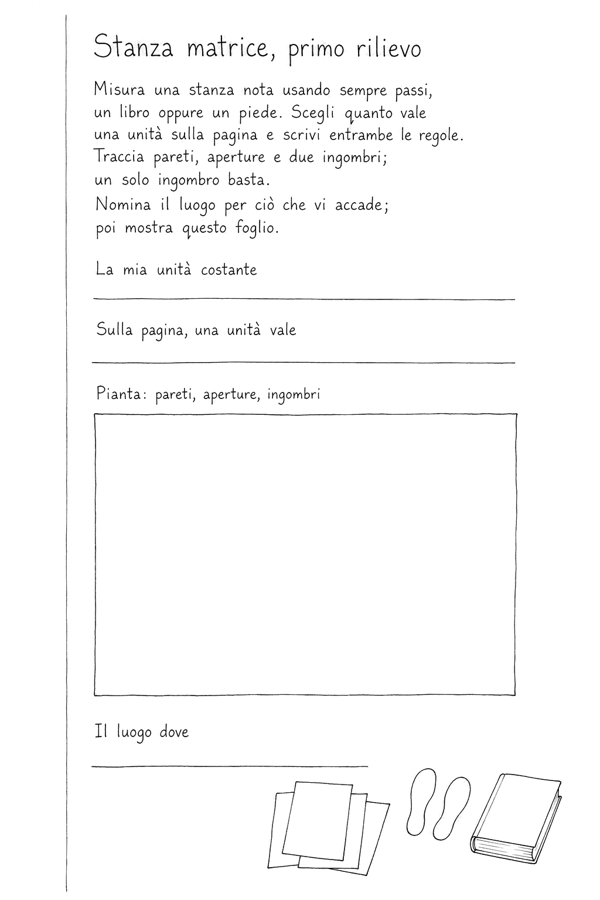

[2] collect: La carta può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.


--- RETURNED: synthetic handwriting (42.914 s) ---


<689061 bytes>


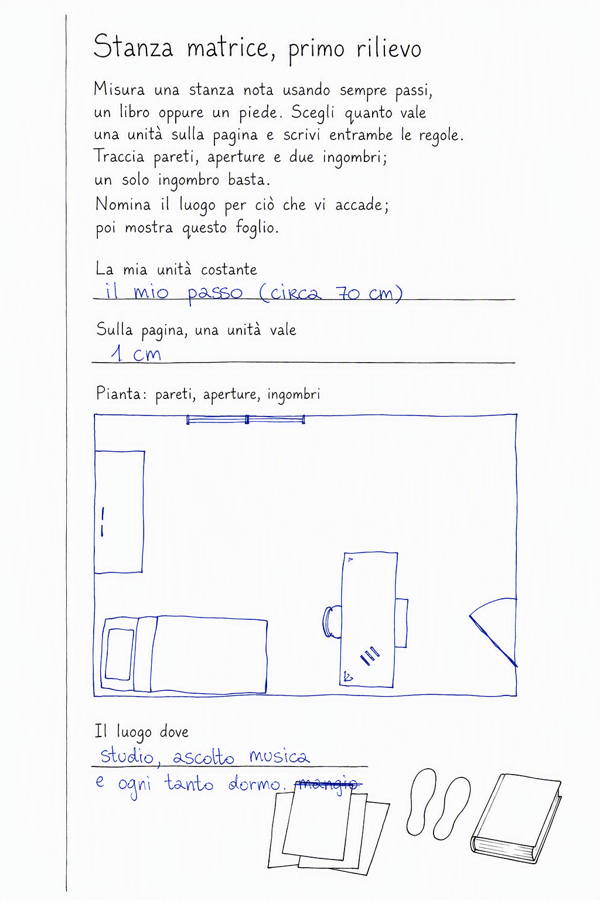


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (12.26 s) ---


{"written":true,"same_sheet":true,"describes":["“il mio passo (circa 70 cm)” in blue on the first answer line","“1 cm” in blue on the second answer line","a blue room plan inside the large box, with a window along the top and a door on the right","blue outlines of a bed at lower left, a cabinet at left, and a table with seats near the center","three short diagonal blue marks and two small symbols on the table","“Studio, ascolto musica” in blue on the line below “Il luogo dove”","“e ogni tanto dormo.” in blue below, followed by the crossed-out word “mangio”"]}



--- SENT: continuing aftn-a58062e9 after return-map ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third of th

--- RETURNED: continuing aftn-a58062e9 after return-map (60.621 s) ---


{"moments":[{"act":"hand_over","id":"route-map","heading":"Tre tratti fanno margine","weights":{"short":{"minutes":8,"lines":["Prendi la mappa del margine.","Copia porta, finestra e tavolo.","Traccia una via e la sua deviazione."]},"standard":{"minutes":22,"lines":["Tre tratti sono rimasti sul tavolo.","Prendi la mappa del margine.","Riporta i contorni dal primo foglio.","Traccia il percorso e la deviazione."]},"extended":{"minutes":32,"lines":["Tre tratti sono rimasti sul tavolo.","Completa la mappa del margine.","Traccia il percorso e la deviazione.","Aggiungi un simbolo alla zona chiusa."]}},"help":[{"after_minutes":3,"lines":["I tre tratti ora cambiano il tavolo.","La prima via passa da quel punto."]},{"after_minutes":7,"lines":["Il primo percorso tocca il tavolo.","La deviazione non lo attraversa."]},{"after_minutes":12,"lines":["Copia porta, finestra e tavolo.","Traccia la prima via nel riquadro.","Poi aggira tavolo e sedute."]},{"after_minutes":18,"lines":["Riporta porta, finest

[3] hand_over: Tre tratti fanno margine



--- SENT: drawing a map ---
The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "Studio, musica e sonno"
Letter this smaller, under the title: "Qui studio, ascolto musica e ogni tanto dormo. Nel riquadro: perimetro, porta a destra, finestra in alto e tavolo. I tre tratti rendono tavolo e sedute invalicabili; dagli un nome. Traccia porta-tavolo-finestra; poi devia. Se serve, apri un varco."
Leave an empty box about a third of the page high, to draw in, with "Mappa, primo percorso e deviazione" lettered above it
Leave one ruled line, long enough for a few words, with "Nuovo nome del tavolo" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Simbolo del margine invalicabile" lettered above it
Leave one ruled line, long enough for a few words, with "Il simbolo significa" lettered above it

What the drawing on the page shows: A broad bl

--- RETURNED: drawing a map (40.941 s) ---


...


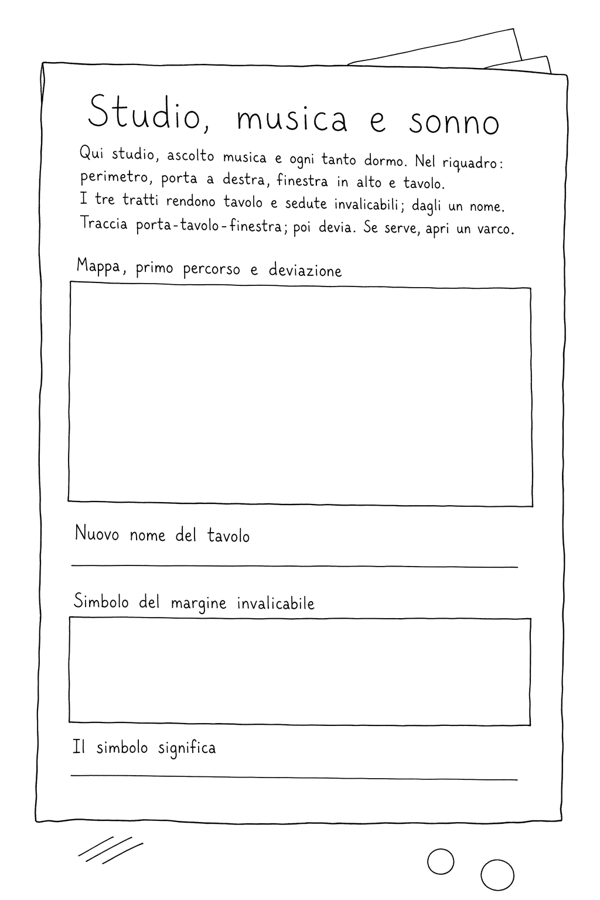

[4] collect: La deviazione può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.
Write only on the FIRST image. The other 1 images are sheets already on the table. Use their content when the first sheet refers to them. Return only the first sheet, with the added handwriting.


--- RETURNED: synthetic handwriting (42.465 s) ---


<755104 bytes>


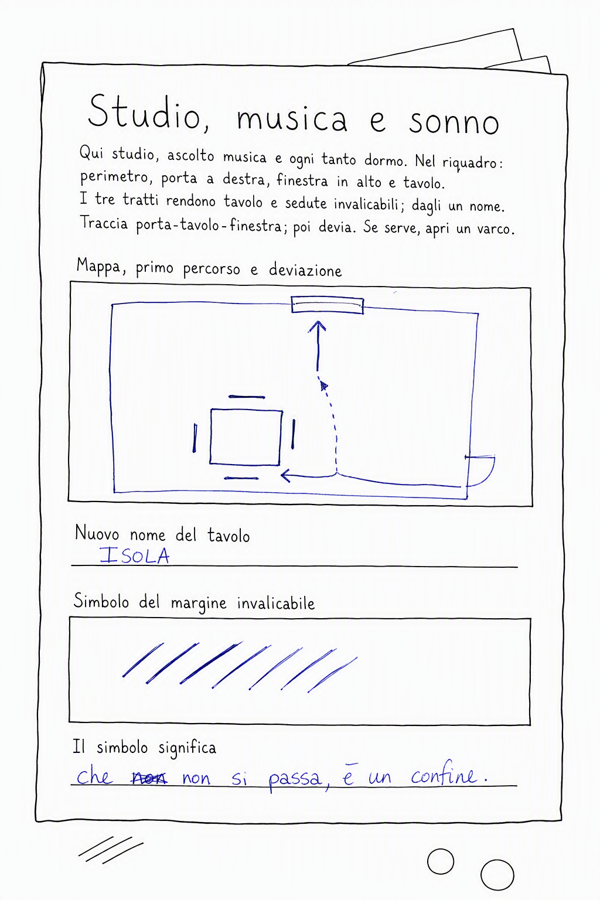


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (7.215 s) ---


{"written":true,"same_sheet":true,"describes":["a blue room outline in the map box, with a window at the top and a door at the right","a rectangular table with short blue lines around it in the lower-left of the map","solid and dashed blue arrowed routes between the door, table and window","“ISOLA” written on the line for the new table name","seven pairs of diagonal blue strokes in the symbol box","“che [crossed-out word] non si passa, è un confine.” written on the bottom line"]}


[5] close: L’atlante si chiude



--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (1.888 s) ---


{"written":false,"same_sheet":true,"describes":[]}


{
  "status": "concluded",
  "reason": "",
  "built_from": {
    "form": "plan-of-a-place-you-know",
    "move": "named-by-what-happens-there"
  },
  "blank_reading": {
    "written": false,
    "same_sheet": true,
    "describes": [],
    "read_at": 1789483741.2407825,
    "degraded": false,
    "metadata": {
      "read_by": "page_reader",
      "request_id": "rq_1cd8cc11",
      "latency_s": 1.89
    }
  },
  "reading_in_continuation_prompt": true,
  "continuations": 1,
  "seconds": 361.797
}
Outcome: concluded 
Cell elapsed: 361.9 s
Artifacts: officina\runs\006-screened-continuation-20260915T144851952272Z


In [4]:
from research.workbench import live_activity


def seen(png: bytes) -> None:
    with Picture.open(io.BytesIO(png)) as picture:
        picture.thumbnail((620, 900))
        preview = io.BytesIO()
        picture.save(preview, format='PNG')
    display(Image(data=preview.getvalue()))


began = time.perf_counter()
try:
    RESULT = await live_activity(RUN, ARGS, show=seen)
    print('Outcome:', RESULT.status, RESULT.reason)
finally:
    print(f'Cell elapsed: {time.perf_counter() - began:.1f} s')
    print('Artifacts:', RUN.relative_to(ROOT))
if RUN.exists():
    (RUN / "prompt-snapshot.json").write_text(
        json.dumps(PROMPT_SNAPSHOT, ensure_ascii=False, indent=2),
        encoding="utf-8", newline="",
    )
    (RUN / "provenance.json").write_text(
        json.dumps(PROVENANCE, indent=2), encoding="utf-8", newline="",
    )


## Transcript and Verification

The transcript distinguishes display messages, generated paper, returned marks and continuations. The checks count what this run actually did, rather than planned moments.

In [5]:
EXPERIENCE = json.loads((RUN / 'experience.json').read_text(encoding='utf-8'))
VERIFICATION = json.loads((RUN / 'verification.json').read_text(encoding='utf-8'))
WALK = json.loads((RUN / 'walk.json').read_text(encoding='utf-8'))
CALLS = json.loads((RUN / 'calls.json').read_text(encoding='utf-8'))
display(Markdown('### ' + EXPERIENCE['title']))
print(EXPERIENCE['overview'])
print(EXPERIENCE['script'])
for number, event in enumerate(WALK['events'], 1):
    print(f"\n{number}. {event['act']} / {event['moment']}")
    print('\n'.join(event['lines']))
    if 'reading' in event:
        print('Synthetic return:', json.dumps(event['reading'], ensure_ascii=False))
    if 'continuation' in event:
        print('Continuation received:', len(event['continuation']['moments']), 'moments')
returns = [event for event in WALK['events'] if event.get('reading', {}).get('written')]
CHECKS = {
    'concluded': WALK['status'] == 'concluded',
    'multiple_returns': len(returns) >= 2,
    'multiple_sheets_within_ceiling': 2 <= len(WALK['pages']) <= ARGS['sheets'],
    'continuation_received': VERIFICATION['continuations'] >= 1,
    'reading_reaches_prompt': VERIFICATION['reading_in_continuation_prompt'],
    'blank_control': not VERIFICATION['blank_reading']['written']
        and not VERIFICATION['blank_reading']['degraded'],
    'no_fallback': not any(event.get('status') == 'fallback' for event in WALK['events']),
}
print(json.dumps({
    'checks': CHECKS, 'sheets': len(WALK['pages']), 'written_returns': len(returns),
    'measured_seconds': VERIFICATION['seconds'],
    'declared_minutes': WALK['declared_minutes'],
}, indent=2))
assert all(CHECKS.values()), CHECKS
print('PASS: complete synthetic multi-exchange game')

### L’atlante della stanza che cambia funzione

Misura una stanza con passi, un libro o un piede, ne disegna la pianta e la trasforma in un luogo inventato. Dalla stampante escono fogli d’atlante personalizzati. Alla fine tiene una mappa completa con scala, percorso, ostacolo e legenda. Non serve altro oltre a carta e matita. Potrebbe non piacere dover misurare la stanza e ridisegnarla quando la prima scala non entra.
IL MONDO Una stanza reale diventa la matrice geometrica di un luogo inventato. Pareti, aperture e ingombri vengono misurati con un’unità corporea o domestica. Lanternina aggiunge conseguenze alle scelte ricevute. L’atlante, i nomi e le proprietà del luogo sono elementi fittizi; le misure e la prima pianta sono osservazioni reali. LA VIA D’ENTRATA La stampante consegna il foglio di rilievo. Sul display Lanternina segnala che la stanza eccede il foglio. Si prende il foglio dalla stampante e si compilano le due regole di scala prima di tracciare la pianta. LA DOMANDA Come può la geometria di una stanza reale diventare la 

## Call Record

Durations are measured wall-clock seconds per logical call. SDK retries and Content Safety requests are not separate rows, so this is not a billing ledger. Physical legibility, handling, photography, delivery waits and comprehension still require a real afternoon.

In [6]:
for number, call in enumerate(CALLS, 1):
    print(f"{number:2} {call['seconds']:8.1f} s {call['status']:6} {call['purpose']}")
print('Artifacts:', RUN.relative_to(ROOT))
print('Notebook iteration:', ITERATION)
print('Prompt fingerprint:', FINGERPRINT)

 1     16.9 s ok     choosing what to build an afternoon out of
 2     93.1 s ok     devising an afternoon
 3     38.5 s ok     drawing a notebook
 4     42.9 s ok     synthetic handwriting
 5     12.3 s ok     reading a page against its blank
 6     60.6 s ok     continuing aftn-a58062e9 after return-map
 7     40.9 s ok     drawing a map
 8     42.5 s ok     synthetic handwriting
 9      7.2 s ok     reading a page against its blank
10      1.9 s ok     reading a page against its blank
Artifacts: officina\runs\006-screened-continuation-20260915T144851952272Z
Notebook iteration: 006-screened-continuation
Prompt fingerprint: 22fa7d484a58


## Editorial Review: 15 September 2026

The run concluded with two sheets, two synthetic returns, one continuation and five executed moments. Model-path time was 361.797 seconds; notebook time was 375.1 seconds. Every current notebook assertion passed, but the brief asked for at least three meaningful exchanges. The checks accept two returns and therefore do not establish full brief compliance.

The activity starts by measuring a known room instead of drawing an invented place. The second page preserves reported positions of the door, window and table and develops three reported marks into a fictional restriction. This uses concrete returned material, but the request remains compressed: an impassable margin can also be opened if needed. The final message is prewritten before the second return and cannot respond to the new name ISOLA. The synthetic drawing also simplifies the original room; image references in this workbench are original pages, not preceding filled pages.

This is a functioning two-exchange construction, not the requested three-exchange correspondence. The prompts do not reliably enforce the brief or guarantee a responsive ending. See [the comparison](comparison-002-004.md) for the distinction between software completion and editorial quality, and [the authored example](authored-example.md) for a proposed target.